# Modélisation de la Consommation Énergétique des Bâtiments de Seattle

---

## Contexte du Projet

**Objectif** : Prédire la consommation énergétique (`SiteEnergyUse(kBtu)`) des bâtiments non résidentiels de Seattle pour aider la ville à atteindre son objectif de **neutralité carbone en 2050**.

**Données** : Relevés de consommation énergétique des bâtiments de Seattle en 2016

**Méthodologie** :
1. Préparation des données (suppression du data leakage)
2. Analyse des features importantes
3. Sélection des features pertinentes
4. Comparaison de plusieurs algorithmes de régression
5. Évaluation et recommandation

---

## 1. Imports et Configuration

In [1]:
# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR


# Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import OneHotEncoder
from category_encoders import BinaryEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

# Métriques
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Utilitaires
import time

In [2]:
!python --version
print('\n'.join(f'{m.__name__} - {m.__version__}' 
                for m in globals().values() 
                if getattr(m, '__version__', None)))

Python 3.13.11
pandas - 2.3.3
numpy - 1.26.4


## 2. Chargement des Données

In [3]:
# Charger les données nettoyées
df_clean = pd.read_pickle('df_clean.pkl')

print("✅ Dataset chargé avec succès")
print(f"📊 Dimensions : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes")
print(f"\n📋 Colonnes disponibles :")
df_clean.info()

print("---"*30)

✅ Dataset chargé avec succès
📊 Dimensions : 1522 lignes × 35 colonnes

📋 Colonnes disponibles :
<class 'pandas.core.frame.DataFrame'>
Index: 1522 entries, 0 to 3375
Data columns (total 35 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   DataYear                         1522 non-null   int64  
 1   BuildingType                     1522 non-null   object 
 2   PrimaryPropertyType              1522 non-null   object 
 3   CouncilDistrictCode              1522 non-null   int64  
 4   Neighborhood                     1522 non-null   object 
 5   Latitude                         1522 non-null   float64
 6   Longitude                        1522 non-null   float64
 7   YearBuilt                        1522 non-null   int64  
 8   NumberofBuildings                1522 non-null   float64
 9   NumberofFloors                   1522 non-null   int64  
 10  PropertyGFATotal                 1522 non-null   int6

## 3/Traitement des Valeurs manquantes du Dataset

In [4]:
# Aperçu rapide des données
valeurs_manquantes =df_clean.isna().sum()[df_clean.isna().sum() > 0]

if len(valeurs_manquantes)>0 :
    print("Valeurs manquantes restantes :")
    print(valeurs_manquantes)
else:
    print("Aucune valeur manquante dans le dataset")

Valeurs manquantes restantes :
LargestPropertyUseType                4
LargestPropertyUseTypeGFA             4
SecondLargestPropertyUseType        691
SecondLargestPropertyUseTypeGFA     691
ThirdLargestPropertyUseType        1178
ThirdLargestPropertyUseTypeGFA     1178
ENERGYSTARScore                     533
SiteEUIWN(kBtu/sf)                    1
SiteEnergyUseWN(kBtu)                 1
dtype: int64


---

**Objectif :**  
**création d'un dataset model sans valeur manquante.**

---

In [5]:
print("\n2️⃣ TRAITEMENT : Usages secondaires et tertiaires")
print("-"*80)

colonnes_a_traiter = {
    'LargestPropertyUseTypeGFA': 0,
    'SecondLargestPropertyUseType': 'None',
    'SecondLargestPropertyUseTypeGFA': 0,
    'ThirdLargestPropertyUseType': 'None',
    'ThirdLargestPropertyUseTypeGFA': 0,
    'ENERGYSTARScore': 0,
    'SiteEnergyUseWN(kBtu)':0,
    'SiteEUIWN(kBtu/sf)':0
}

for colonne, valeur_remplacement in colonnes_a_traiter.items():
    df_clean[colonne] = df_clean[colonne].fillna(valeur_remplacement)
    print(f"✅ Rempli les valeurs manquantes de {colonne} par {repr(valeur_remplacement)}")


2️⃣ TRAITEMENT : Usages secondaires et tertiaires
--------------------------------------------------------------------------------
✅ Rempli les valeurs manquantes de LargestPropertyUseTypeGFA par 0
✅ Rempli les valeurs manquantes de SecondLargestPropertyUseType par 'None'
✅ Rempli les valeurs manquantes de SecondLargestPropertyUseTypeGFA par 0
✅ Rempli les valeurs manquantes de ThirdLargestPropertyUseType par 'None'
✅ Rempli les valeurs manquantes de ThirdLargestPropertyUseTypeGFA par 0
✅ Rempli les valeurs manquantes de ENERGYSTARScore par 0
✅ Rempli les valeurs manquantes de SiteEnergyUseWN(kBtu) par 0
✅ Rempli les valeurs manquantes de SiteEUIWN(kBtu/sf) par 0


### 3.1 Traitement de LargestPropertyUseType 

In [6]:
pct_manquant = (df_clean['LargestPropertyUseType'].isnull().sum() / len(df_clean)) * 100

print(f"Pourcentage de valeurs manquantes dans LargestPropertyUseType est de {pct_manquant:.2f}%")

Pourcentage de valeurs manquantes dans LargestPropertyUseType est de 0.26%


Nous remplaçons les valeurs manquantes de **LargestPropertyUseType** par celles de **PrimaryPropertyType** car ces deux colonnes décrivent toutes deux l'usage principal du bâtiment.  
Et le taux minimum de valeur manquante n'a pas de risque de tronquer les résultat.  
Cette redondance d'information nous permet de compléter les données manquantes de manière cohérente.

In [7]:
df_clean['LargestPropertyUseType'] = df_clean['LargestPropertyUseType'].fillna(df_clean['PrimaryPropertyType'])

print("✅ Valeurs manquantes de LargestPropertyUseType remplies avec PrimaryPropertyType")

✅ Valeurs manquantes de LargestPropertyUseType remplies avec PrimaryPropertyType


In [8]:
valeurs_manquantes =df_clean.isnull().sum()[df_clean.isnull().sum() > 0]
if len(valeurs_manquantes)>0 :
    print("Valeurs manquantes restantes :")
    print(valeurs_manquantes)
else:
    print("Aucune valeur manquante dans le dataset")

Aucune valeur manquante dans le dataset


## 3/ Mise en Echelle Log les features avec des Outliers

#### 3.1 Visualisation des features

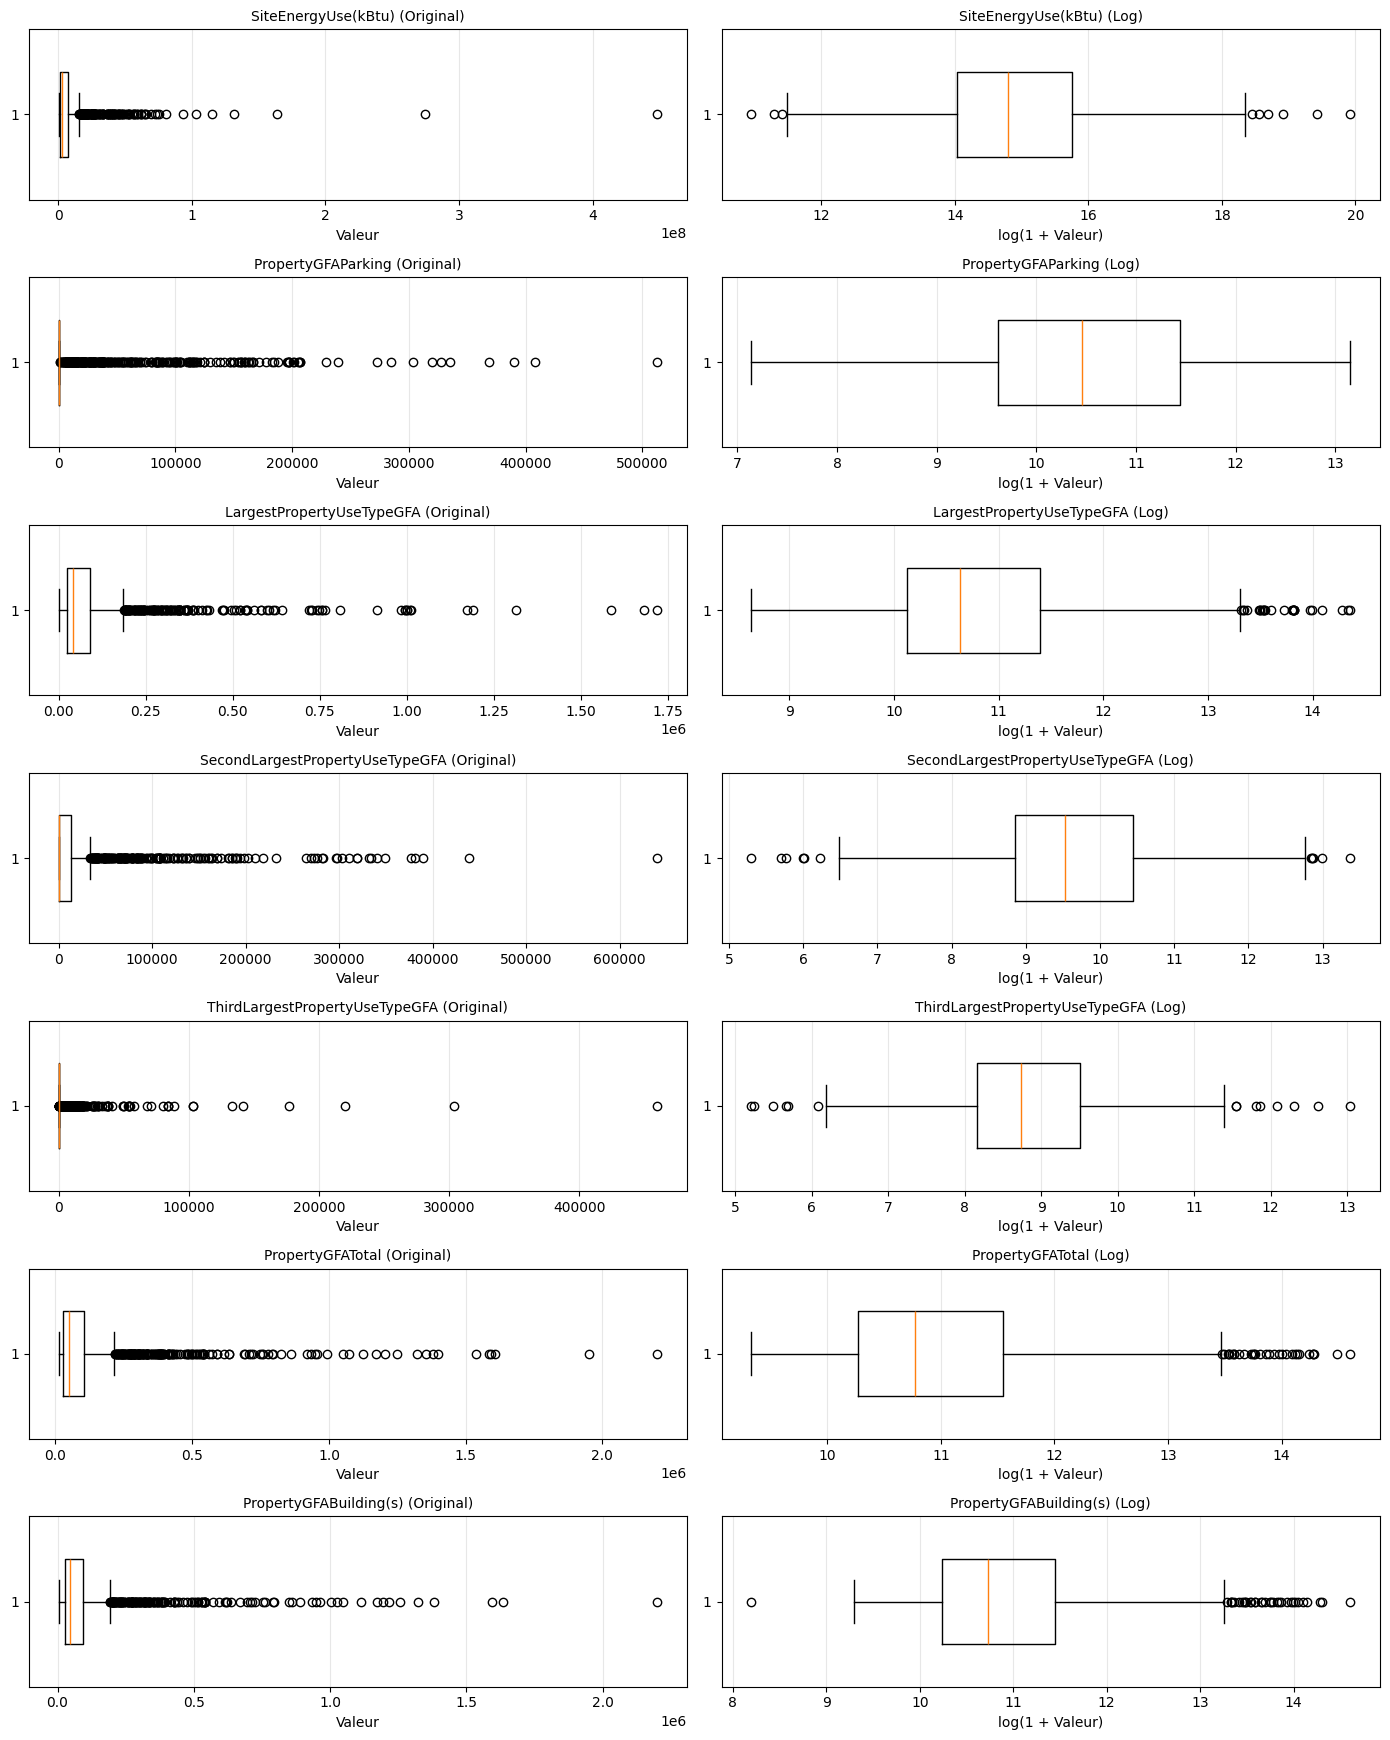

In [9]:
variables_to_log = [
    'SiteEnergyUse(kBtu)',
    'PropertyGFAParking',
    'LargestPropertyUseTypeGFA',
    'SecondLargestPropertyUseTypeGFA',
    'ThirdLargestPropertyUseTypeGFA',
    'PropertyGFATotal',
    'PropertyGFABuilding(s)'
]

fig, axes = plt.subplots(len(variables_to_log), 2, figsize=(14, len(variables_to_log) * 2.5))

for idx, col in enumerate(variables_to_log):
    data_positive = df_clean[df_clean[col] > 0][col]
    
    # Boxplot AVANT
    axes[idx, 0].boxplot(df_clean[col].dropna(), vert=False, widths=0.5)
    axes[idx, 0].set_title(f'{col} (Original)', fontsize=10)
    axes[idx, 0].set_xlabel('Valeur')
    axes[idx, 0].grid(True, alpha=0.3, axis='x')
    
    # Boxplot APRÈS
    if len(data_positive) > 0:
        log_data = np.log1p(data_positive)
        axes[idx, 1].boxplot(log_data, vert=False, widths=0.5)
        axes[idx, 1].set_title(f'{col} (Log)', fontsize=10)
        axes[idx, 1].set_xlabel('log(1 + Valeur)')
        axes[idx, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('boxplots_avant_apres_log.png', dpi=300, bbox_inches='tight')
plt.show()

#### 3.2 Mise en Echelle log

In [10]:
# Création des features en échelle log (log10)
cols_to_log = [
    'SiteEnergyUse(kBtu)',
    'PropertyGFATotal',
    'PropertyGFABuilding(s)',
]

for col in cols_to_log:
    df_clean[f'{col}_log'] = np.log10(df_clean[col])

log_cols = [f'{col}_log' for col in cols_to_log]
display(df_clean[log_cols].describe())

,SiteEnergyUse(kBtu)_log,PropertyGFATotal_log,PropertyGFABuilding(s)_log
count,1522.000000,1522.000000,1522.000000
mean,6.480051,4.788504,4.751197
std,0.554576,0.412172,0.389955
min,4.756889,4.052502,3.560624
25%,6.094367,4.459423,4.444786
50%,6.424040,4.679132,4.660120
75%,6.844601,5.015629,4.971496
max,8.651651,6.342423,6.342423


## 4/ Encodage des variables catégorielles

In [11]:
print("📊 INVENTAIRE DES VARIABLES CATÉGORIELLES")
print("="*80)

# Identifier les colonnes de type 'object' (texte)
colonnes_categorielles = df_clean.select_dtypes(include=['object']).columns.tolist()

print(f"\n✅ Nombre de variables catégorielles : {len(colonnes_categorielles)}\n")

# Analyser chaque variable catégorielle
for col in colonnes_categorielles:
    n_categories = df_clean[col].nunique()
    print(f"📌 {col}")
    print(f"   Nombre de catégories : {n_categories}")
    print(f"   Valeurs : {df_clean[col].value_counts().head(5).to_dict()}")
    print()
print(f"✓ Dimensions : {df_clean.shape}")
print("="*80)

📊 INVENTAIRE DES VARIABLES CATÉGORIELLES

✅ Nombre de variables catégorielles : 8

📌 BuildingType
   Nombre de catégories : 5
   Valeurs : {'NonResidential': 1420, 'Nonresidential COS': 79, 'Campus': 12, 'SPS-District K-12': 10, 'Nonresidential WA': 1}

📌 PrimaryPropertyType
   Nombre de catégories : 21
   Valeurs : {'Small- and Mid-Sized Office': 285, 'Other': 236, 'Warehouse': 185, 'Large Office': 168, 'Mixed Use Property': 111}

📌 Neighborhood
   Nombre de catégories : 19
   Valeurs : {'DOWNTOWN': 350, 'GREATER DUWAMISH': 323, 'LAKE UNION': 142, 'MAGNOLIA / QUEEN ANNE': 142, 'EAST': 113}

📌 ListOfAllPropertyUseTypes
   Nombre de catégories : 365
   Valeurs : {'Office': 132, 'Office, Parking': 119, 'Non-Refrigerated Warehouse': 100, 'Non-Refrigerated Warehouse, Office': 61, 'Other': 54}

📌 LargestPropertyUseType
   Nombre de catégories : 56
   Valeurs : {'Office': 482, 'Non-Refrigerated Warehouse': 197, 'Retail Store': 93, 'Other': 90, 'Hotel': 76}

📌 SecondLargestPropertyUseType
   

In [12]:
# 1. OneHotEncoder 
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_cols = ['BuildingType']
ohe_encoded = ohe.fit_transform(df_clean[ohe_cols])
ohe_df = pd.DataFrame(
    ohe_encoded,
    columns=ohe.get_feature_names_out(ohe_cols),
    index=df_clean.index
)

# 2. BinaryEncoder
binary_cols = [
    'PrimaryPropertyType',
    'Neighborhood',
    'LargestPropertyUseType',
    'SecondLargestPropertyUseType',
    'ThirdLargestPropertyUseType'
]

binary_encoder = BinaryEncoder(cols=binary_cols)
binary_df = binary_encoder.fit_transform(df_clean[binary_cols])

# Supprimer les colonnes catégorielles originales
colonnes_a_supprimer = ohe_cols + binary_cols
df_clean = df_clean.drop(columns=colonnes_a_supprimer)

df_clean = pd.concat([df_clean, ohe_df, binary_df], axis=1)

print(f"✓ Nouvelles dimensions : {df_clean.shape}")
df_clean.info()

✓ Nouvelles dimensions : (1522, 65)
<class 'pandas.core.frame.DataFrame'>
Index: 1522 entries, 0 to 3375
Data columns (total 65 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   DataYear                         1522 non-null   int64  
 1   CouncilDistrictCode              1522 non-null   int64  
 2   Latitude                         1522 non-null   float64
 3   Longitude                        1522 non-null   float64
 4   YearBuilt                        1522 non-null   int64  
 5   NumberofBuildings                1522 non-null   float64
 6   NumberofFloors                   1522 non-null   int64  
 7   PropertyGFATotal                 1522 non-null   int64  
 8   PropertyGFAParking               1522 non-null   int64  
 9   PropertyGFABuilding(s)           1522 non-null   int64  
 10  ListOfAllPropertyUseTypes        1522 non-null   object 
 11  LargestPropertyUseTypeGFA        1522 non-null   fl

## 5. Features supplémentaires : RATIOS ET PROPORTIONS
création de 7 ratios :
- **building_age** : age des bâtiments
- **parking_ratio** surfaceparking/surface total
- **main_use_ratio** type d'utilisation/surface total
- **energie_ratio** ratio type energie (pour le calcul de ratio des 3 features energies)
- **Electricity(kBtu)_ratio** = ratio electricité
- **SteamUse(kBtu)_ratio** = ratio steamUse
- **NaturalGas(kBtu)_ratio** = ratio gaz
- **second_use_ratio**  2nd utilisation surface /surface total
- **third_use_ratio**  3e utilisation surface /surface total
- **usable_area**: surface totale - surfaceParking

In [23]:
# 1. RATIOS surfaceparking/surface total et type d'utilisation/surface total
df_clean['building_age'] = df_clean['DataYear'] - df_clean['YearBuilt']
df_clean['parking_ratio'] = df_clean['PropertyGFAParking'] / df_clean['PropertyGFATotal']
df_clean['usable_area'] = df_clean['PropertyGFATotal'] - df_clean['PropertyGFAParking']

# Ratios d'énergie avec une boucle
# Calculer les ratios uniquement pour Electricity et NaturalGas
energy_sources = ['Electricity(kBtu)', 'NaturalGas(kBtu)'] 

df_clean['totale_energie'] = sum(df_clean[source] for source in energy_sources)

for source in energy_sources:
    df_clean[f'{source}_ratio'] = df_clean[source] / df_clean['totale_energie']
    df_clean[f'{source}_ratio'] = df_clean[f'{source}_ratio'].replace([np.inf, -np.inf], 0).fillna(0)

# Ratios d'utilisation avec une boucle
use_types = [
    ('LargestPropertyUseTypeGFA', 'main_use_ratio'),
    ('SecondLargestPropertyUseTypeGFA', 'second_use_ratio'),
    ('ThirdLargestPropertyUseTypeGFA', 'third_use_ratio')
]

for gfa_col, ratio_name in use_types:
    df_clean[ratio_name] = df_clean[gfa_col] / df_clean['PropertyGFATotal']

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1522 entries, 0 to 3375
Data columns (total 74 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   DataYear                         1522 non-null   int64  
 1   CouncilDistrictCode              1522 non-null   int64  
 2   Latitude                         1522 non-null   float64
 3   Longitude                        1522 non-null   float64
 4   YearBuilt                        1522 non-null   int64  
 5   NumberofBuildings                1522 non-null   float64
 6   NumberofFloors                   1522 non-null   int64  
 7   PropertyGFATotal                 1522 non-null   int64  
 8   PropertyGFAParking               1522 non-null   int64  
 9   PropertyGFABuilding(s)           1522 non-null   int64  
 10  ListOfAllPropertyUseTypes        1522 non-null   object 
 11  LargestPropertyUseTypeGFA        1522 non-null   float64
 12  SecondLargestPropertyUseT

In [24]:
print(f"Le nouveau dataset est composé de {df_clean.shape[0]} lignes et de {df_clean.shape[1]} colonnes" )
print(df_clean.info())

Le nouveau dataset est composé de 1522 lignes et de 74 colonnes
<class 'pandas.core.frame.DataFrame'>
Index: 1522 entries, 0 to 3375
Data columns (total 74 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   DataYear                         1522 non-null   int64  
 1   CouncilDistrictCode              1522 non-null   int64  
 2   Latitude                         1522 non-null   float64
 3   Longitude                        1522 non-null   float64
 4   YearBuilt                        1522 non-null   int64  
 5   NumberofBuildings                1522 non-null   float64
 6   NumberofFloors                   1522 non-null   int64  
 7   PropertyGFATotal                 1522 non-null   int64  
 8   PropertyGFAParking               1522 non-null   int64  
 9   PropertyGFABuilding(s)           1522 non-null   int64  
 10  ListOfAllPropertyUseTypes        1522 non-null   object 
 11  LargestPropertyUseTypeG

**Analyse**  
Il y a une corrélation entre la surface et la consommation.
Il n'y a pas très peu de corrélation entre l'année de constructions et la consommations 

Décision d'encodage pour chaque variable :

    OneHotEncoder : BuildingType ; ComplianceStatus / car peu de catégories
    BinaryEncoder : PrimaryPropertyType ; Neighborhood ; LargestPropertyUseType ; SecondLargestPropertyUseType; ThirdLargestPropertyUseType
    pour ListOfAllPropertyUseTypes, il y a trop de catégorie (371) donc on ne l'utilisera pas.



In [25]:
print(f"Après la suppression des Outlier. Le nouveau dataset est composé de {df_clean.shape[0]} lignes et de {df_clean.shape[1]} colonnes" )

Après la suppression des Outlier. Le nouveau dataset est composé de 1522 lignes et de 74 colonnes


## Préparation des Données

### 3.1 Suppression des colonnes pour éviter le Data Leakage

**Colonnes à supprimer** :
- Variables calculées à partir de la target (EUI, etc.)
- Composantes de la consommation (Electricity, Gas, Steam)
- Émissions de GES (liées directement à la consommation)

In [26]:
colonnes_a_supprimer = [
    # Variables calculées à partir de la target
    'SiteEUI(kBtu/sf)',
    'SiteEUIWN(kBtu/sf)',
    'SourceEUI(kBtu/sf)',
    'SourceEUIWN(kBtu/sf)',
    'SiteEnergyUseWN(kBtu)',
    
    # Composantes de la consommation (= data leakage direct)
    'Electricity(kBtu)',
    'NaturalGas(kBtu)',
    'SteamUse(kBtu)',
    
    # Émissions (liées directement à la consommation)
    'TotalGHGEmissions',
    'GHGEmissionsIntensity',
]

# Créer le dataset pour la modélisation
df_model = df_clean.drop(columns=colonnes_a_supprimer)

print(f"✅ Colonnes supprimées : {len(colonnes_a_supprimer)}")
print(f"📊 Nouvelles dimensions : {df_model.shape}")
df_clean.info()

✅ Colonnes supprimées : 10
📊 Nouvelles dimensions : (1522, 64)
<class 'pandas.core.frame.DataFrame'>
Index: 1522 entries, 0 to 3375
Data columns (total 74 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   DataYear                         1522 non-null   int64  
 1   CouncilDistrictCode              1522 non-null   int64  
 2   Latitude                         1522 non-null   float64
 3   Longitude                        1522 non-null   float64
 4   YearBuilt                        1522 non-null   int64  
 5   NumberofBuildings                1522 non-null   float64
 6   NumberofFloors                   1522 non-null   int64  
 7   PropertyGFATotal                 1522 non-null   int64  
 8   PropertyGFAParking               1522 non-null   int64  
 9   PropertyGFABuilding(s)           1522 non-null   int64  
 10  ListOfAllPropertyUseTypes        1522 non-null   object 
 11  LargestPropertyUseTypeGF

## 6. Matrice de Correlations

**Objectif** : Identifier les features les plus prédictives pour simplifier le modèle.


✅ Matrice calculée pour 42 variables UTILISABLES


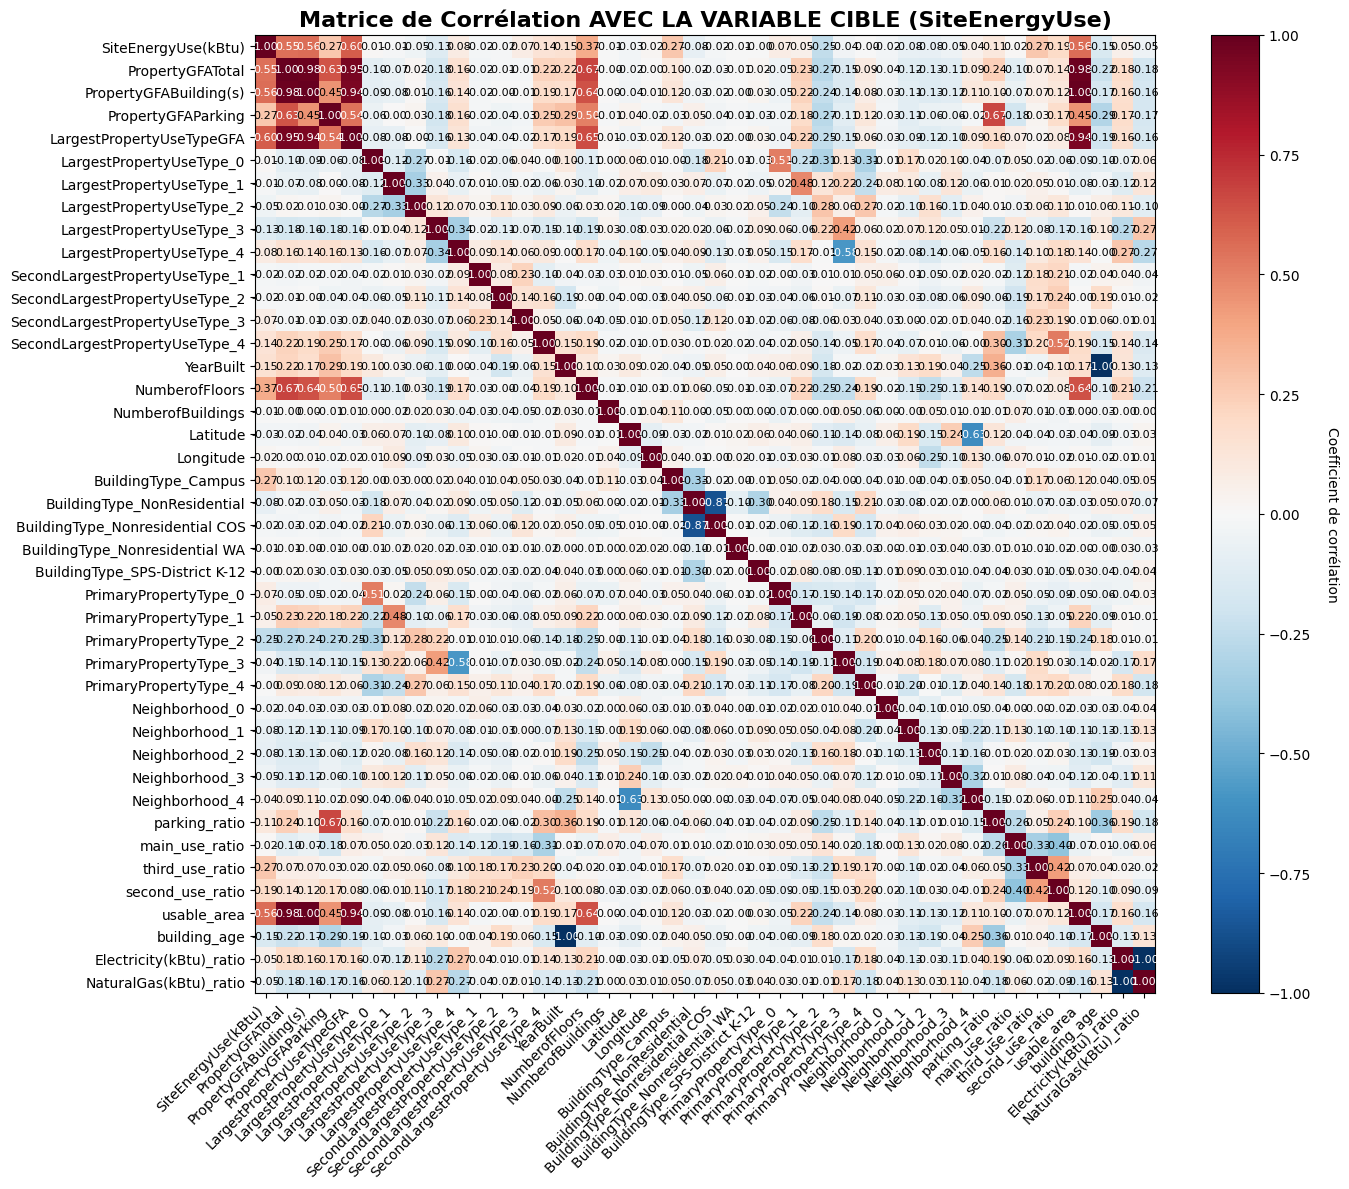



🎯 CORRÉLATIONS AVEC LA VARIABLE CIBLE (SiteEnergyUse)
   Variables structurelles UNIQUEMENT - utilisables pour la prédiction
--------------------------------------------------------------------------------

📈 Top TOUTES les corrélations (ordre décroissant) :
    1. LargestPropertyUseTypeGFA                : +0.603  [MOYENNE   ]
    2. PropertyGFABuilding(s)                   : +0.562  [MOYENNE   ]
    3. usable_area                              : +0.562  [MOYENNE   ]
    4. PropertyGFATotal                         : +0.553  [MOYENNE   ]
    5. NumberofFloors                           : +0.372  [FAIBLE    ]
    6. BuildingType_Campus                      : +0.272  [FAIBLE    ]
    7. third_use_ratio                          : +0.270  [FAIBLE    ]
    8. PropertyGFAParking                       : +0.269  [FAIBLE    ]
    9. second_use_ratio                         : +0.193  [FAIBLE    ]
   10. YearBuilt                                : +0.149  [FAIBLE    ]
   11. SecondLargestPropertyU

In [27]:
colonnes_importantes = [
    'SiteEnergyUse(kBtu)',           # Variable cible
    'PropertyGFATotal',              # Surface totale
    'PropertyGFABuilding(s)',        # Surface bâtiment
    'PropertyGFAParking',            # Surface parking
    'LargestPropertyUseTypeGFA',     # Surface usage principal
    'LargestPropertyUseType_0', 
    'LargestPropertyUseType_1', 
    'LargestPropertyUseType_2', 
    'LargestPropertyUseType_3', 
    'LargestPropertyUseType_4', 
    'SecondLargestPropertyUseType_1',
    'SecondLargestPropertyUseType_2', 
    'SecondLargestPropertyUseType_3',
    'SecondLargestPropertyUseType_4',
    'YearBuilt',                     # Année construction
    'NumberofFloors',                # Nombre d'étages
    'NumberofBuildings',             # Nombre de bâtiments
    'Latitude',                      # Position géographique
    'Longitude',                      # Position géographique
    'BuildingType_Campus',                            
    'BuildingType_NonResidential',                   
    'BuildingType_Nonresidential COS',                
    'BuildingType_Nonresidential WA',                 
    'BuildingType_SPS-District K-12', 
    'PrimaryPropertyType_0',
    'PrimaryPropertyType_1',
    'PrimaryPropertyType_2',
    'PrimaryPropertyType_3',
    'PrimaryPropertyType_4',
    'Neighborhood_0',
    'Neighborhood_1', 
    'Neighborhood_2', 
    'Neighborhood_3', 
    'Neighborhood_4', 
    'parking_ratio',                   #nouvelle variables
    'main_use_ratio',             
    'third_use_ratio',
    'second_use_ratio',
    'usable_area', 
    'building_age',
    'Electricity(kBtu)_ratio',
    'NaturalGas(kBtu)_ratio'
]

# Créer un sous-dataframe avec ces colonnes
df_colonne = df_clean[colonnes_importantes].copy()

# Calculer la matrice de corrélation
correlation_matrix = df_colonne.corr()

print(f"\n✅ Matrice calculée pour {len(colonnes_importantes)} variables UTILISABLES")

# Créer la visualisation
fig, ax = plt.subplots(figsize=(14, 12))

# Créer la heatmap
im = ax.imshow(correlation_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)

# Ajouter les labels
ax.set_xticks(np.arange(len(colonnes_importantes)))
ax.set_yticks(np.arange(len(colonnes_importantes)))
ax.set_xticklabels(colonnes_importantes, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(colonnes_importantes, fontsize=10)

# Ajouter les valeurs dans chaque case
for i in range(len(colonnes_importantes)):
    for j in range(len(colonnes_importantes)):
        value = correlation_matrix.iloc[i, j]
        text_color = 'white' if abs(value) > 0.5 else 'black'
        text = ax.text(j, i, f'{value:.2f}', 
                      ha="center", va="center", color=text_color, fontsize=8)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Coefficient de corrélation', rotation=270, labelpad=20)

# Titre
ax.set_title('Matrice de Corrélation AVEC LA VARIABLE CIBLE (SiteEnergyUse)', 
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)

# Analyser les corrélations avec la variable cible
print("\n🎯 CORRÉLATIONS AVEC LA VARIABLE CIBLE (SiteEnergyUse)")
print("   Variables structurelles UNIQUEMENT - utilisables pour la prédiction")
print("-"*80)

target_correlations = correlation_matrix['SiteEnergyUse(kBtu)'].drop('SiteEnergyUse(kBtu)').sort_values(ascending=False)

print("\n📈 Top TOUTES les corrélations (ordre décroissant) :")
for i, (var, corr) in enumerate(target_correlations.items(), 1):
    # Interpréter la force
    if abs(corr) > 0.7:
        force = "FORTE     "
    elif abs(corr) > 0.4:
        force = "MOYENNE   "
    else:
        force = "FAIBLE    "
    
    print(f"   {i:2d}. {var:40s} : {corr:+.3f}  [{force}]")

print("="*80)

### 3.2 Séparation Features (X) et Target (y)

In [28]:
# Séparer features et target
X = df_model.drop(columns=['SiteEnergyUse(kBtu)_log'])
y = df_model['SiteEnergyUse(kBtu)_log']

print("✅ Séparation effectuée")
print(f"📊 X (features) : {X.shape}")
print(f"🎯 y (target) : {y.shape}")
print(f"\n📋 Features disponibles ({X.shape[1]}) :")
print(X.columns.tolist())

✅ Séparation effectuée
📊 X (features) : (1522, 63)
🎯 y (target) : (1522,)

📋 Features disponibles (63) :
['DataYear', 'CouncilDistrictCode', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEnergyUse(kBtu)', 'DefaultData', 'ComplianceStatus', 'z_score', 'PropertyGFATotal_log', 'PropertyGFABuilding(s)_log', 'BuildingType_Campus', 'BuildingType_NonResidential', 'BuildingType_Nonresidential COS', 'BuildingType_Nonresidential WA', 'BuildingType_SPS-District K-12', 'PrimaryPropertyType_0', 'PrimaryPropertyType_1', 'PrimaryPropertyType_2', 'PrimaryPropertyType_3', 'PrimaryPropertyType_4', 'Neighborhood_0', 'Neighborhood_1', 'Neighborhood_2', 'Neighborhood_3', 'Neighborhood_4', 'LargestPropertyUseType_0', 'LargestPropertyUseType_1', 'LargestPropertyU

## 8/ Sélection des Features

In [29]:
# Sélection des 5 features principales
features_selectionnees_SVR = [
    'PropertyGFATotal_log',
    'main_use_ratio',
    'building_age',
    'NumberofFloors'
]

features_selectionnees = [
    'PropertyGFATotal_log',              # Surface totale en echelle log
    'PropertyGFABuilding(s)_log',        # Surface bâtiment en echelle log
    'PropertyGFAParking',            # Surface parking
    'SecondLargestPropertyUseTypeGFA', # Surface usage secondaire
    'ThirdLargestPropertyUseTypeGFA',  # Surface usage tertiaire
    
    'PrimaryPropertyType_0',
    'PrimaryPropertyType_1',
    'PrimaryPropertyType_2',
    'PrimaryPropertyType_3',
    'PrimaryPropertyType_4',
    'LargestPropertyUseType_0', 
    'LargestPropertyUseType_1', 
    'LargestPropertyUseType_2', 
    'LargestPropertyUseType_3', 
    'LargestPropertyUseType_4', 
    
    'NumberofFloors',                # Nombre d'étages
    'NumberofBuildings',             # Nombre de bâtiments
    'Latitude',                      # Position géographique
    'Longitude',                      # Position géographique
    'BuildingType_Campus',                            
    'BuildingType_NonResidential',                   
    'BuildingType_Nonresidential COS',                
    'BuildingType_Nonresidential WA',                 
    'BuildingType_SPS-District K-12', 
    'Neighborhood_0',
    'Neighborhood_1', 
    'Neighborhood_2', 
    'Neighborhood_3', 
    'Neighborhood_4',
    'CouncilDistrictCode',
    
    'parking_ratio',                   
    'main_use_ratio',              
    'third_use_ratio',
    'second_use_ratio',
    'usable_area', 
    'building_age',
    
    'Electricity(kBtu)_ratio',
    'NaturalGas(kBtu)_ratio'
]

# Créer le nouveau dataset simplifié
X_svr = df_model[features_selectionnees_SVR]
y_svr = df_model['SiteEnergyUse(kBtu)_log']

X = df_model[features_selectionnees]
y = df_model['SiteEnergyUse(kBtu)_log']

In [30]:
X_train_svr, X_test_svr, y_train_svr, y_test_svr = train_test_split(
    X_svr, 
    y_svr, 
    test_size=0.2, 
    random_state=42
)

# Split Train/Test pour les modèles Random Forest et Linear Regression
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

print("✅ Split effectué")
print(f"📊 Ensemble d'entraînement : {X_train.shape[0]} lignes")
print(f"📊 Ensemble de test : {X_test.shape[0]} lignes")

✅ Split effectué
📊 Ensemble d'entraînement : 1217 lignes
📊 Ensemble de test : 305 lignes


## 9/ GridSearch CV

In [31]:
# Standardiser AVANT le GridSearch
scaler_svr = StandardScaler()
X_train_svr_scaled = scaler_svr.fit_transform(X_train_svr)
X_test_svr_scaled = scaler_svr.transform(X_test_svr)

# Grille de paramètres
param_grid = {
    'kernel': ['linear'],
    'C': [1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

# Relancer le GridSearch avec les données standardisées
grid_search.fit(X_train_svr_scaled, y_train_svr)

# Résultats
print("\n✅ GridSearch terminé !")
print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score R² (CV) : {grid_search.best_score_:.4f}")

# Récupérer le meilleur modèle SVR
best_svr = grid_search.best_estimator_

print("="*110)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ GridSearch terminé !
Meilleurs paramètres : {'C': 100, 'epsilon': 0.1, 'kernel': 'linear'}
Meilleur score R² (CV) : 0.5865


## 10. Modélisation et Comparaison d'Algorithmes

**Approche méthodologique** : Tester plusieurs algorithmes du plus simple au plus complexe.

**Algorithmes testés** :
1. **Dummy Regressor** (baseline) - Prédit toujours la moyenne
2. **Linear Regression** - Relation linéaire simple
3. **SVR** (Support Vector Regression) - Relation non-linéaire
4. **Random Forest** - Ensemble d'arbres de décision

**Métriques d'évaluation** :
- **R²** : Coefficient de détermination (0 à 1, plus c'est élevé, mieux c'est)
- **RMSE** : Erreur quadratique moyenne (en kBtu)
- **MAE** : Erreur absolue moyenne (en kBtu)
- **MAPE** : Erreur absolue moyenne en pourcentage

In [32]:
modeles = {
    'Dummy (Baseline)': Pipeline([
        ('model', DummyRegressor(strategy='mean'))
    ]),

    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),

    'SVR': Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR(kernel='linear', C=100, epsilon=0.1))
]),

    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(
            n_estimators=50,
            max_depth=8,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42
        ))
])
}

resultats = []

for nom, pipeline in modeles.items():
    print(f"\n🔧 Entraînement : {nom}")
    
    # Mesurer le temps d'entraînement
    start_time = time.time()
    
    # Entraîner le modèle
    pipeline.fit(X_train, y_train)
    
    # Temps d'entraînement
    train_time = round(time.time() - start_time,4)
    
    # Prédictions
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    
   # Calcul des métriques pour TRAIN
    r2_train = round(r2_score(y_train, y_pred_train),4)
    mae_train = round(mean_absolute_error(y_train, y_pred_train),1)
    mse_train = round(mean_squared_error(y_train, y_pred_train),1)  
    rmse_train = round(np.sqrt(mse_train),1) 

    # Calcul des métriques pour TEST
    r2_test = round(r2_score(y_test, y_pred_test),2)
    ecart_R2 = round(r2_train - r2_test,4)
    mae_test = round(mean_absolute_error(y_test, y_pred_test),2)
    mse_test = round(mean_squared_error(y_test, y_pred_test),2)  
    rmse_test = round(np.sqrt(mse_test),2) 
    
    # MAPE (en évitant les divisions par zéro)
    mask = y_test != 0
    mape = round(np.mean(np.abs((y_test[mask] - y_pred_test[mask]) / y_test[mask])) * 100,1)
    
    # Stocker les résultats
    resultats.append({
        'Modèle': nom,
        'Temps (s)': train_time,
        'R² Train': r2_train,
        'R² Test': r2_test,
        'Ecart R²' : ecart_R2,
        'MAE Train': mae_train,
        'MAE Test': mae_test,
        'RMSE Train': rmse_train,
        'RMSE Test': rmse_test,
        'MAPE (%)': mape
    })
    
   
    # Création d'un tableau comparatif
    resultats_df = pd.DataFrame(resultats).sort_values('R² Test', ascending=False)

print("\n📊 TABLEAU COMPARATIF DES MODÈLES")
print("="*110)
print(resultats_df.to_string(index=False))
print("="*110)
  
print("\n✅ ENTRAÎNEMENT TERMINÉ !")


🔧 Entraînement : Dummy (Baseline)

🔧 Entraînement : Linear Regression

🔧 Entraînement : SVR

🔧 Entraînement : Random Forest

📊 TABLEAU COMPARATIF DES MODÈLES
           Modèle  Temps (s)  R² Train  R² Test  Ecart R²  MAE Train  MAE Test  RMSE Train  RMSE Test  MAPE (%)
Linear Regression     0.1485    0.7474     0.71    0.0374        0.2      0.23         0.3       0.32       3.7
              SVR   230.0336    0.7423     0.71    0.0323        0.2      0.23         0.3       0.30       3.6
    Random Forest     1.6960    0.8170     0.71    0.1070        0.2      0.23         0.3       0.32       3.7
 Dummy (Baseline)     0.0028    0.0000    -0.00    0.0000        0.4      0.45         0.5       0.57       7.1

✅ ENTRAÎNEMENT TERMINÉ !


In [ ]:
print(f" Le modèle Linear Regression parait meilleur")
print(f" il est rapide: 0.0682
- Un écart des deux R² est de 0.O323

**analyse**
Le métriques MAE et RMSE sont proches de zéro.
La moyenne des erreurs (MAE) est basse (inférieur à 5)
Nos 3 modèles font mieux que la Baseline.

Le modèle Linear Regression parait meilleur, il est rapide, et l'écart entre ke R² test et le R² Train est minime

## 11. Résultats et Comparaison

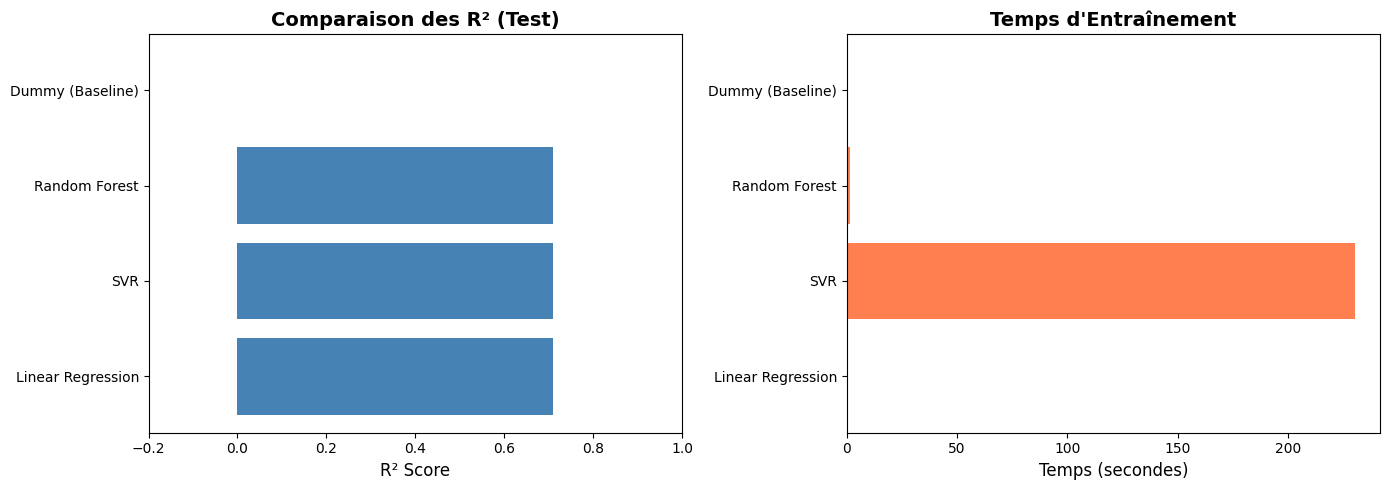

[CV] END ....................C=1, epsilon=0.1, kernel=linear; total time=   0.7s
[CV] END ....................C=1, epsilon=0.5, kernel=linear; total time=   0.2s
[CV] END ....................C=1, epsilon=0.5, kernel=linear; total time=   0.2s
[CV] END ..................C=10, epsilon=0.01, kernel=linear; total time=   3.1s
[CV] END ...................C=10, epsilon=0.5, kernel=linear; total time=   0.4s
[CV] END .................C=100, epsilon=0.01, kernel=linear; total time=  17.5s
[CV] END ..................C=100, epsilon=0.5, kernel=linear; total time=   2.5s
[CV] END ...................C=1, epsilon=0.01, kernel=linear; total time=   0.9s
[CV] END ....................C=1, epsilon=0.5, kernel=linear; total time=   0.2s
[CV] END ..................C=10, epsilon=0.01, kernel=linear; total time=   2.8s
[CV] END ...................C=10, epsilon=0.5, kernel=linear; total time=   0.4s
[CV] END ...................C=10, epsilon=0.5, kernel=linear; total time=   0.4s
[CV] END .................C=

In [33]:
# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² Score comparison
axes[0].barh(resultats_df['Modèle'], resultats_df['R² Test'], color='steelblue')
axes[0].set_xlabel('R² Score', fontsize=12)
axes[0].set_title('Comparaison des R² (Test)', fontsize=14, fontweight='bold')
axes[0].set_xlim(-0.2, 1.0)

# Temps d'entraînement
axes[1].barh(resultats_df['Modèle'], resultats_df['Temps (s)'], color='coral')
axes[1].set_xlabel('Temps (secondes)', fontsize=12)
axes[1].set_title('Temps d\'Entraînement', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 12. Visualisation de la Prédiction

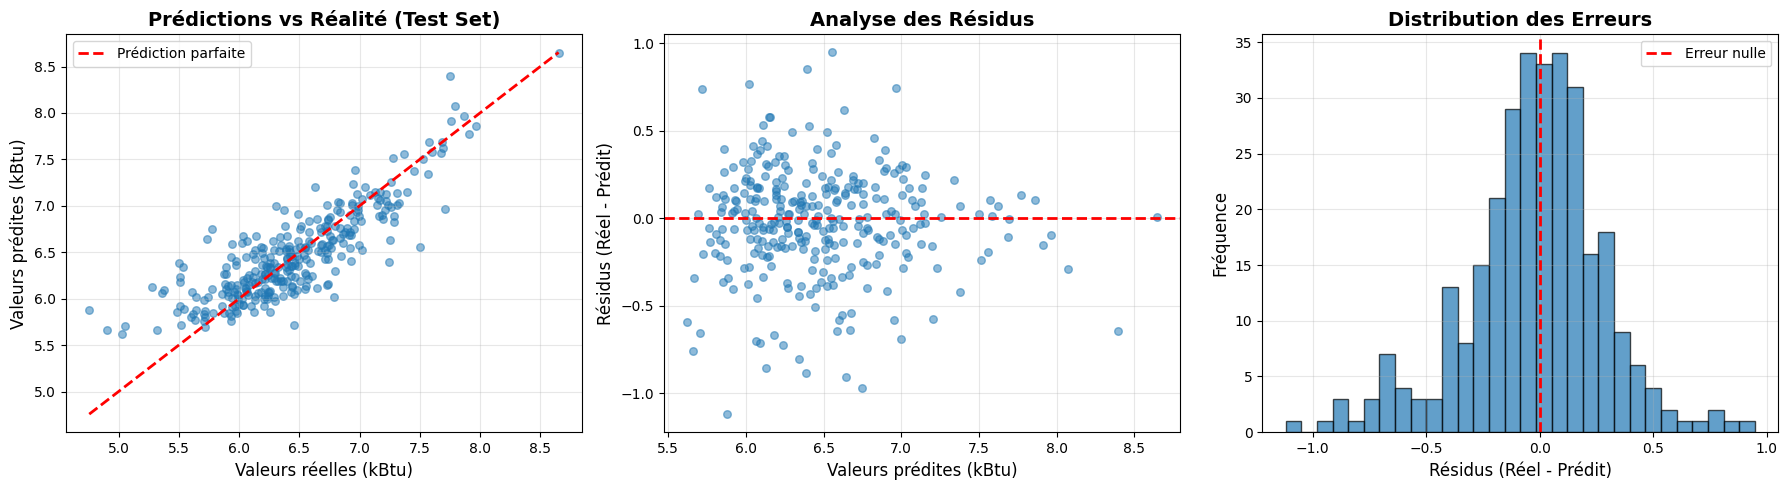

In [34]:
# Récupérer le modèle Linear Regression entraîné
lr_model = modeles['Linear Regression']

# Faire les prédictions (si pas déjà fait)
y_pred_train_lr = lr_model.predict(X_train)
y_pred_test_lr = lr_model.predict(X_test)

# Créer une figure avec 3 sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ============================================================
# 1️⃣ GRAPHIQUE 1 : Valeurs réelles vs Prédictions (TEST)
# ============================================================
axes[0].scatter(y_test, y_pred_test_lr, alpha=0.5, s=30)
axes[0].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles (kBtu)', fontsize=12)
axes[0].set_ylabel('Valeurs prédites (kBtu)', fontsize=12)
axes[0].set_title('Prédictions vs Réalité (Test Set)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ============================================================
# 2️⃣ GRAPHIQUE 2 : Résidus (erreurs de prédiction)
# ============================================================
residus = y_test - y_pred_test_lr
axes[1].scatter(y_pred_test_lr, residus, alpha=0.5, s=30)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Valeurs prédites (kBtu)', fontsize=12)
axes[1].set_ylabel('Résidus (Réel - Prédit)', fontsize=12)
axes[1].set_title('Analyse des Résidus', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# ============================================================
# 3️⃣ GRAPHIQUE 3 : Distribution des erreurs
# ============================================================
axes[2].hist(residus, bins=30, edgecolor='black', alpha=0.7)
axes[2].axvline(x=0, color='r', linestyle='--', lw=2, label='Erreur nulle')
axes[2].set_xlabel('Résidus (Réel - Prédit)', fontsize=12)
axes[2].set_ylabel('Fréquence', fontsize=12)
axes[2].set_title('Distribution des Erreurs', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Analyse**
Prédictions vs Réalité : l'ensemble des points sont proches de la ligne rouge qui représente la prédiction idéale
Analyse des résidus: les points ne forment pas de schéma précis.
Distribution des Erreurs : graphique sous forme de cloche, proche de zéro.

## 13/ Les features importantes

📊 TOP 10 FEATURES - XGBOOST (Feature Importance)
                        Feature  Importance
           PropertyGFATotal_log    0.136752
          PrimaryPropertyType_2    0.132172
          PrimaryPropertyType_0    0.102063
          PrimaryPropertyType_3    0.094575
       LargestPropertyUseType_4    0.031889
BuildingType_Nonresidential COS    0.030596
     PropertyGFABuilding(s)_log    0.028642
       LargestPropertyUseType_0    0.025234
    BuildingType_NonResidential    0.025120
        Electricity(kBtu)_ratio    0.023429


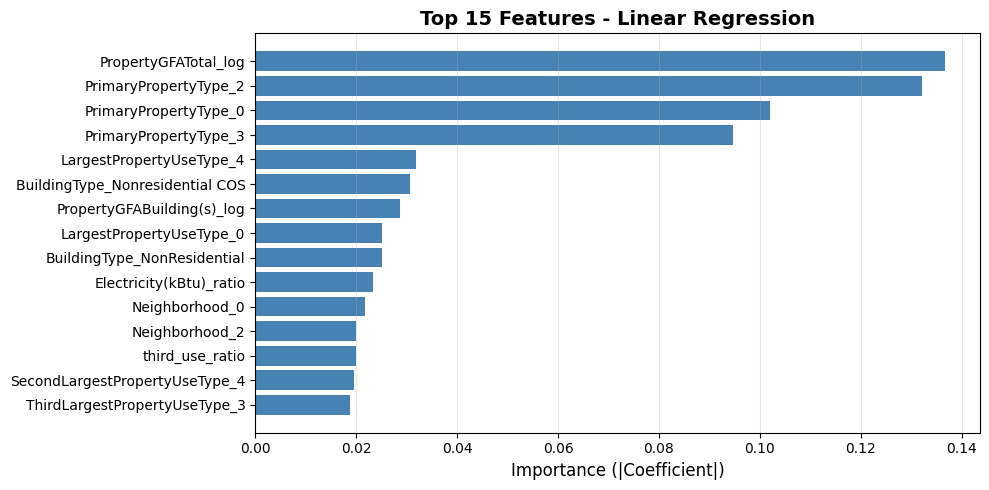

In [35]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline  
from sklearn.preprocessing import StandardScaler 

# Version simplifiée (recommandée)
modeles['XGBoost'] = XGBRegressor(random_state=42, n_estimators=100)
modeles['XGBoost'].fit(X_train, y_train)

# Extraire les feature importances directement
importances_xgb = modeles['XGBoost'].feature_importances_

# Créer le DataFrame
importance_xgb = pd.DataFrame({
    'Feature': features_selectionnees,
    'Importance': importances_xgb
}).sort_values('Importance', ascending=False)

print("📊 TOP 10 FEATURES - XGBOOST (Feature Importance)")
print("="*70)
print(importance_xgb[['Feature', 'Importance']].head(10).to_string(index=False))
print("="*70)


# ============================================================
# 3️⃣ VISUALISATIONS
# ============================================================

fig, axes = plt.subplots(1, 1, figsize=(10, 5))

# GRAPHIQUE 1 : Top 15 Linear Regression
top15_lr = importance_xgb.head(15)
axes.barh(range(len(top15_lr)), top15_lr['Importance'], color='steelblue')
axes.set_yticks(range(len(top15_lr)))
axes.set_yticklabels(top15_lr['Feature'], fontsize=10)
axes.set_xlabel('Importance (|Coefficient|)', fontsize=12)
axes.set_title('Top 15 Features - Linear Regression', fontsize=14, fontweight='bold')
axes.invert_yaxis()  # Plus important en haut
axes.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


## 13. Conclusions et Recommandations

### Synthèse des Résultats

**Modèle recommandé** : Linear Regression avec un Dataframe: 1601

**Performances** :
- R² Test ~ 0.62 , le modèle explique 62% de la variance de la consommation énergétique
- R² Train ~ 0.84 , prédiction du supérieur sur le Train
- Très rapide à entraîner (<0.1s)

### 37 Features clés utilisées
**Surface** : PropertyGFATotal, PropertyGFABuilding(s), LargestPropertyUseTypeGFA
**Structure** : NumberofFloors, NumberofBuildings
**Features engineerées** : parking_ratio, main_use_ratio, usable_area, building_age, second_use_ratio, third_use_ratio
**Localisation** : Latitude, Longitude, variables Neighborhood encodées
**Type de bâtiment** : variables BuildingType et PrimaryPropertyType encodées
**Certification** : ENERGYSTARScore

### Recommandations pour la Ville de Seattle

1. **Cibler les grands bâtiments** : La taille est le facteur principal de consommation
2. **Apporter de l'homogeneité au dataset**:  recolter plus de données pour avoir une meilleure prediction
3. **Apporter une analyse specifique sur les individus "Other/Autres"** : les hopitaux, tribunaux et Data Center ont une consommation anormale d'energie. Une comparaison avec des batiments similaire dans des régions aux climats similaires apporterait une meilleure prediction. 
